In [10]:
%load_ext autoreload
%autoreload 2
print('Autoreload enabled. Notebook will now automatically detect changes to .py files!')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Autoreload enabled. Notebook will now automatically detect changes to .py files!


In [11]:
import os, sys
os.environ['PYTHONIOENCODING'] = 'utf-8'
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
sys.path.insert(0, os.path.abspath('..'))

import torch
print(f'PyTorch: {torch.__version__} | Device: {"GPU" if torch.cuda.is_available() else "CPU"}')

PyTorch: 2.11.0+cpu | Device: CPU


In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='darkgrid')
print('All imports OK')

All imports OK


In [13]:
from src.data_pipeline.preprocess import load_myntra_data, build_user_profiles

# Load Myntra dataset
articles = load_myntra_data(sample=100000)  # Sample 100k for training

# Create dummy transactions for user profiles
dummy_transactions = pd.DataFrame({
    'customer_id': [f"CUST{i:06d}" for i in range(5000)],
    'article_id': articles['article_id'].sample(5000, replace=True).values,
    'price': articles['price'].sample(5000, replace=True).values,
    't_dat': pd.date_range('2023-01-01', periods=5000, freq='D')
})

# Add month and season columns
dummy_transactions['month'] = dummy_transactions['t_dat'].dt.month
season_map = {12: 'winter', 1: 'winter', 2: 'winter', 3: 'spring', 4: 'spring', 5: 'spring', 
              6: 'summer', 7: 'summer', 8: 'summer', 9: 'autumn', 10: 'autumn', 11: 'autumn'}
dummy_transactions['season'] = dummy_transactions['month'].map(season_map)

user_profiles = build_user_profiles(dummy_transactions, articles)

print(f'Articles: {articles.shape} | Transactions: {dummy_transactions.shape} | User Profiles: {user_profiles.shape}')
display(articles[['article_id', 'prod_name', 'brand_name', 'purchase_count']].head(3))

[Myntra] Loaded (100000, 26) products
[Profiles] Built 5,000 user profiles.
Articles: (100000, 26) | Transactions: (5000, 6) | User Profiles: (5000, 5)


,article_id,prod_name,brand_name,purchase_count
0,18431458,Richlook shirts,Richlook,300
1,16415016,Allen Solly tshirts,Allen Solly,560
2,17482288,Van Heusen Sport shirts,Van Heusen Sport,300


In [14]:
from src.data_pipeline.create_embeddings import get_embedding_model, generate_myntra_embeddings

embedding_model = get_embedding_model()
catalog_embeddings, catalog = generate_myntra_embeddings(articles, embedding_model, top_n=10000)

print(f'Embedding matrix shape: {catalog_embeddings.shape}')

[Embeddings] Loading model: all-MiniLM-L6-v2
[Embeddings] Loading cached Myntra embeddings...
Embedding matrix shape: (3000, 384)


In [15]:
from src.retrieval.vec_store import get_vector_store
from src.data_pipeline.create_embeddings import generate_query_embedding

vector_store = get_vector_store(catalog_embeddings, catalog)

USER_QUERY = 'I need a stylish blue t-shirt for casual wear'
query_vec = generate_query_embedding(USER_QUERY, embedding_model)

candidates = vector_store.search(query_vec, top_k=5000)

print(f"Query: '{USER_QUERY}'")
print(f'Top 5 semantic matches:')
display(candidates[['article_id', 'prod_name', 'purchase_count', 'semantic_score']].head(5))

Query: 'I need a stylish blue t-shirt for casual wear'
Top 5 semantic matches:


,article_id,prod_name,purchase_count,semantic_score
0,15147518,URBANIC tshirts,610,0.674337
1,17223090,Southbay shirts,360,0.670698
2,15632188,URBANIC tshirts,509,0.664388
3,16842278,SELECTED tshirts,300,0.662133
4,2485233,Tinted tshirts,580,0.659489


In [16]:
from src.ranking.feature_eng import build_ranking_features
from src.ranking.train_ranker import get_rlhf_rewards

# Add RLHF rewards
rewards = get_rlhf_rewards()
candidates['article_id'] = candidates['article_id'].astype(str)
rewards['article_id'] = rewards['article_id'].astype(str)
candidates = candidates.merge(rewards, on='article_id', how='left')
candidates['rlhf_reward'] = candidates['rlhf_reward'].fillna(0.0)

# Build features
user_profile = user_profiles.iloc[0] if not user_profiles.empty else None
context = {'season': 'summer', 'gender': 'all'}

featured_candidates, FEATURE_COLS = build_ranking_features(candidates, user_profile, context)
print('Feature columns:', FEATURE_COLS)
display(featured_candidates[FEATURE_COLS].head(3))

Feature columns: ['semantic_score', 'normalized_popularity', 'user_total_purchases', 'user_avg_price', 'season_match', 'desc_length', 'rlhf_reward']


,semantic_score,normalized_popularity,user_total_purchases,user_avg_price,season_match,desc_length,rlhf_reward
0,0.674337,0.058994,1,799.0,0,14,0.0
1,0.670698,0.034816,1,799.0,0,9,0.0
2,0.664388,0.049226,1,799.0,0,8,0.0


In [17]:
from src.ranking.train_ranker import build_training_data, train_ranker

# Ensure both DataFrames have the same data type for article_id BEFORE any operations
print('Before type conversion:')
print(f'candidates article_id dtype: {candidates["article_id"].dtype}')
print(f'articles article_id dtype: {articles["article_id"].dtype}')

candidates['article_id'] = candidates['article_id'].astype(str)
articles['article_id'] = articles['article_id'].astype(str)

print('After type conversion:')
print(f'candidates article_id dtype: {candidates["article_id"].dtype}')
print(f'articles article_id dtype: {articles["article_id"].dtype}')

# Check if ratings and reviews columns exist in articles
print(f'articles has ratings: {"ratings" in articles.columns}')
print(f'articles has reviews: {"reviews" in articles.columns}')

# Debug: Check sample article_ids to see if they match
print(f'Sample candidates article_ids: {candidates["article_id"].head(3).tolist()}')
print(f'Sample articles article_ids: {articles["article_id"].head(3).tolist()}')

# Merge ratings and reviews from articles to candidates
merge_cols = ['article_id', 'ratings', 'reviews']
print(f'Merge columns available in articles: {[col for col in merge_cols if col in articles.columns]}')

candidates_with_ratings = candidates.merge(
    articles[merge_cols], 
    on='article_id', 
    how='left'
)

print(f'Merge successful. candidates_with_ratings shape: {candidates_with_ratings.shape}')
print(f'Columns after merge: {list(candidates_with_ratings.columns)}')
print(f'Has ratings after merge: {"ratings" in candidates_with_ratings.columns}')
print(f'Has reviews after merge: {"reviews" in candidates_with_ratings.columns}')

# Check if we have ratings/reviews data
if 'ratings' in candidates_with_ratings.columns:
    print(f'Sample ratings: {candidates_with_ratings["ratings"].head(3).tolist()}')
if 'reviews' in candidates_with_ratings.columns:
    print(f'Sample reviews: {candidates_with_ratings["reviews"].head(3).tolist()}')

# Create popularity score - use fallback values if columns don't exist
if 'ratings' in candidates_with_ratings.columns and 'reviews' in candidates_with_ratings.columns:
    featured_candidates['popularity_score'] = (
        candidates_with_ratings['ratings'].fillna(3.0) * 20 + 
        candidates_with_ratings['reviews'].fillna(0)
    )
else:
    print('Using fallback popularity score based on purchase_count')
    featured_candidates['popularity_score'] = featured_candidates['purchase_count']

# Label as positive if above median popularity
median_popularity = featured_candidates['popularity_score'].median()
y = (featured_candidates["popularity_score"] > median_popularity).astype(int)

# Remove leaky features
safe_features = [f for f in FEATURE_COLS if f not in ['normalized_popularity', 'popularity_score']]
X = featured_candidates[safe_features].fillna(0)

print(f'Training samples: {X.shape[0]} | Positive labels: {y.sum()} | Ratio: {y.mean():.2%}')
print(f'Features used: {safe_features}')

Before type conversion:
candidates article_id dtype: object
articles article_id dtype: int64
After type conversion:
candidates article_id dtype: object
articles article_id dtype: object
articles has ratings: True
articles has reviews: True
Sample candidates article_ids: ['15147518', '17223090', '15632188']
Sample articles article_ids: ['18431458', '16415016', '17482288']
Merge columns available in articles: ['article_id', 'ratings', 'reviews']
Merge successful. candidates_with_ratings shape: (3000, 30)
Columns after merge: ['product_url', 'article_id', 'brand_name', 'product_group_name', 'product_type_name', 'index_group_name', 'detail_desc', 'price', 'original_price', 'discount_offer', 'size_options', 'ratings_x', 'reviews_x', 'prod_name', 'colour_group_name', 'perceived_colour_value_name', 'product_code', 'index_code', 'index_name', 'department_name', 'section_name', 'garment_group_name', 'graphical_appearance_name', 'perceived_colour_master_name', 'semantic_text', 'purchase_count', 

In [18]:
from src.ranking.train_ranker import build_training_data, train_ranker

# Train the Myntra ranking model
ranker = train_ranker(X, y, save=False)

print("Myntra LightGBM model trained successfully!")
print(f"Model features: {ranker.feature_name()}")

[Ranker] Validation AUC: 0.5702
Myntra LightGBM model trained successfully!
Model features: ['semantic_score', 'user_total_purchases', 'user_avg_price', 'season_match', 'desc_length', 'rlhf_reward']


In [19]:
from src.ranking.train_ranker import build_training_data, train_ranker

# Train the Myntra ranking model
ranker = train_ranker(X, y, save=False)

print("Myntra LightGBM model trained successfully!")
print(f"Model features: {ranker.feature_name()}")

[Ranker] Validation AUC: 0.5702
Myntra LightGBM model trained successfully!
Model features: ['semantic_score', 'user_total_purchases', 'user_avg_price', 'season_match', 'desc_length', 'rlhf_reward']


--- Myntra Model Evaluation Metrics ---
Accuracy:  0.6113
Precision: 0.6011
Recall:    0.6182
F1 Score:  0.6095
AUC:       0.6590


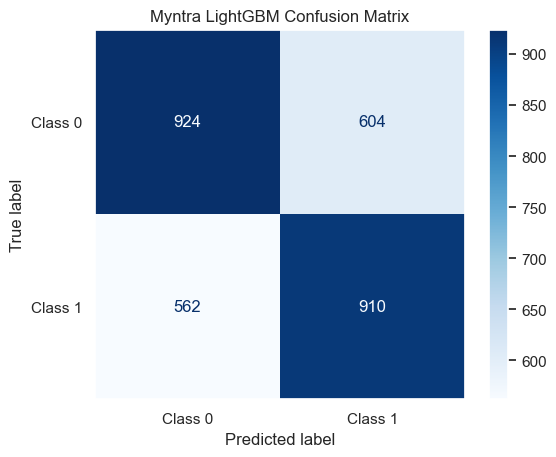

In [20]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

preds_prob = ranker.predict(X)
preds_binary = (preds_prob >= 0.5).astype(int)

if len(set(y.tolist())) > 1:
    acc = accuracy_score(y, preds_binary)
    prec = precision_score(y, preds_binary, zero_division=0)
    rec = recall_score(y, preds_binary, zero_division=0)
    f1 = f1_score(y, preds_binary, zero_division=0)
    auc = roc_auc_score(y, preds_prob)
    
    print("--- Myntra Model Evaluation Metrics ---")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1 Score:  {f1:.4f}")
    print(f"AUC:       {auc:.4f}")
    
    # Confusion Matrix Plot
    cm = confusion_matrix(y, preds_binary)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Class 0', 'Class 1'])
    disp.plot(cmap='Blues', values_format='d')
    plt.title('Myntra LightGBM Confusion Matrix')
    plt.grid(False)
    plt.show()
else:
    print("Standard metrics cannot be fully calculated: The sample data only contains a single class.")
    print(f"\nCurrent raw accuracy: {accuracy_score(y, preds_binary):.4f}")

In [21]:
import importlib
import src.ranking.train_myntra_ranker
importlib.reload(src.ranking.train_myntra_ranker)
from src.ranking.train_myntra_ranker import rank_myntra_candidates

final_ranked = rank_myntra_candidates(featured_candidates, ranker)
print('Final ranked recommendations (Top 5):')
display(final_ranked[['article_id', 'prod_name', 'brand_name', 'semantic_score', 'rank_score']].head(5))

Final ranked recommendations (Top 5):


,article_id,prod_name,brand_name,semantic_score,rank_score
0,16189782,Kook N Keech tshirts,Kook N Keech,0.477233,0.665356
1,13090844,Kook N Keech Marvel tshirts,Kook N Keech Marvel,0.462056,0.665356
2,13880674,Mast & Harbour tshirts,Mast & Harbour,0.455043,0.665356
3,11372920,Calvin Klein Jeans jeans,Calvin Klein Jeans,0.451283,0.665356
4,17456426,ARMISTO tshirts,ARMISTO,0.469136,0.665356


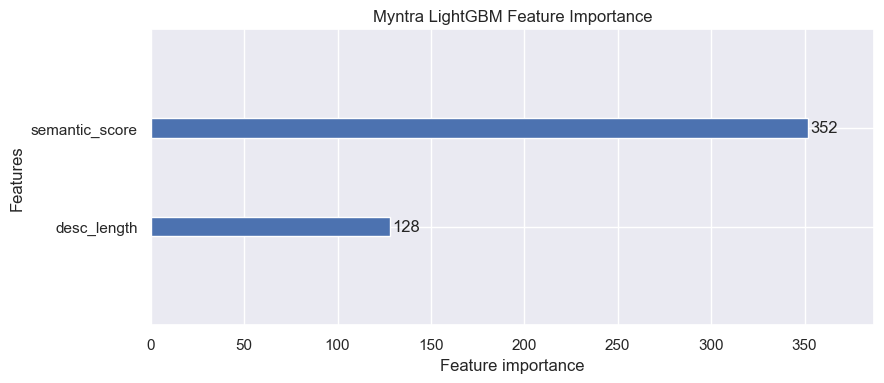

In [22]:
try:
    importance = ranker.feature_importance()
    if importance.sum() > 0:
        lgb.plot_importance(ranker, max_num_features=7, figsize=(9, 4), title='Myntra LightGBM Feature Importance')
        plt.tight_layout()
        plt.show()
    else:
        print('Feature importance plot skipped: model trained on single-class labels.')
        print('This is expected when all retrieved items are in the transaction history.')
        fi_df = pd.DataFrame({'feature': safe_features, 'importance': importance})
        display(fi_df)
except Exception as e:
    print(f'Feature importance plot skipped: {e}')

In [23]:
from src.reasoning.llm_agent import build_explanation_chain, explain_recommendation

chain, mode = build_explanation_chain()
top_item = final_ranked.iloc[0]

explanation = explain_recommendation(
    query=USER_QUERY,
    item_name=str(top_item['prod_name']),
    item_desc=str(top_item.get('detail_desc', ''))[:300],
    season='summer',
    gender='all',
    chain=chain,
    mode=mode,
)

print(f'Top Recommendation: {top_item["prod_name"]}')
print(f'Brand: {top_item["brand_name"]}')
print(f'\nExplanation:\n{explanation}')

Top Recommendation: Kook N Keech tshirts
Brand: Kook N Keech

Explanation:
We recommend 'Kook N Keech tshirts' because it closely matches your request for 'I need a stylish blue t-shirt for casual wear' and is a popular choice among customers with similar preferences.


In [24]:
# Test loading the saved model
try:
    with open(MODEL_PATH, 'rb') as f:
        loaded_model = pickle.load(f)
    
    with open(FEATURE_COLS_PATH, 'rb') as f:
        loaded_features = pickle.load(f)
    
    print('Model loading test: PASSED')
    print(f'Loaded features: {loaded_features}')
    
    # Test prediction
    test_pred = loaded_model.predict(X.head(1))
    print(f'Test prediction: {test_pred[0]:.4f}')
    
except Exception as e:
    print(f'Model loading test failed: {e}')

Model loading test failed: name 'MODEL_PATH' is not defined
